## Session 28 : Q1-9 - Emotions dataset for NLP
#### Link of Dataset : https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

In [1]:
'''
Q1. Loading the Dataset
'''

import pandas as pd

# Load the Dataset
df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"]
)

# Display First 10 Rows
print(df.head(10))

# Display Dataset Shape
print("\nDataset Shape:", df.shape)

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love

Dataset Shape: (16000, 2)

Missing Values:
text        0
emotions    0
dtype: int64


In [2]:
'''
Q2. Exploring Target Labels
'''

from sklearn.preprocessing import LabelEncoder

# Display Unique Emotion Labels
print("Unique Emotion Labels:")
print(df["emotions"].unique())

# Apply Label Encoding
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["emotions"])

# Create Label Mapping
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("\nLabel Mapping:")
print(label_mapping)

# Display First 10 Rows
print("\nUpdated Dataset:")
print(df.head(10))

Unique Emotion Labels:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Label Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

Updated Dataset:
                                                text  emotions  label
0                            i didnt feel humiliated   sadness      4
1  i can go from feeling so hopeless to so damned...   sadness      4
2   im grabbing a minute to post i feel greedy wrong     anger      0
3  i am ever feeling nostalgic about the fireplac...      love      3
4                               i am feeling grouchy     anger      0
5  ive been feeling a little burdened lately wasn...   sadness      4
6  ive been taking or milligrams or times recomme...  surprise      5
7  i feel as confused about life as a teenager or...      fear      1
8  i have been with petronas for years i feel tha...       joy      2
9                                i feel romantic too      

In [3]:
'''
Q3. Lowercasing
'''

# Store Original Text
df["original_text"] = df["text"]

# Convert Text to Lowercase
df["text"] = df["text"].str.lower()

# Display Before and After
comparison = pd.DataFrame({
    "Before": df["original_text"].head(5),
    "After": df["text"].head(5)
})

print(comparison)

# Note
print("\nWhy Lowercasing is Important in NLP:")
print("Lowercasing converts all text to a common format.")
print("It treats words like 'Happy' and 'happy' as the same word,")
print("which reduces duplicate vocabulary and improves model performance.")

                                              Before  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                               After  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  

Why Lowercasing is Important in NLP:
Lowercasing converts all text to a common format.
It treats words like 'Happy' and 'happy' as the same word,
which reduces duplicate vocabulary and improves model performance.


In [4]:
'''
Q4. Removing Punctuation
'''

import string

# Function to Remove Punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

# Store Text Before Removing Punctuation
df["before_punctuation"] = df["text"]

# Apply Function
df["text"] = df["text"].apply(remove_punctuation)

# Display Before and After
comparison = pd.DataFrame({
    "Before": df["before_punctuation"].head(5),
    "After": df["text"].head(5)
})

print(comparison)

                                              Before  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                               After  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


In [5]:
'''
Q5. Removing Numbers
'''

import re

# Function to Remove Numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

# Store Text Before Removing Numbers
df["before_numbers"] = df["text"]

# Apply Function
df["text"] = df["text"].apply(remove_numbers)

# Display Before and After
comparison = pd.DataFrame({
    "Before": df["before_numbers"].head(5),
    "After": df["text"].head(5)
})

print(comparison)

                                              Before  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                               After  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


In [6]:
'''
Q6. Removing Emojis & Special Characters
'''

# Function to Remove Emojis & Special Characters
def remove_emojis_special(text):
    return text.encode("ascii", "ignore").decode("ascii")

# Store Text Before Cleaning
df["before_special"] = df["text"]

# Apply Function
df["text"] = df["text"].apply(remove_emojis_special)

# Display Before and After
comparison = pd.DataFrame({
    "Before": df["before_special"].head(5),
    "After": df["text"].head(5)
})

print(comparison)

                                              Before  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                               After  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


In [7]:
'''
Q7. Removing Stopwords
'''

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download Required Resources
nltk.download("punkt")
nltk.download("stopwords")

# Load English Stopwords
stop_words = set(stopwords.words("english"))

# Function to Remove Stopwords
def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

# Apply Function
df["text"] = df["text"].apply(remove_stopwords)

# Display 5 Cleaned Samples
print(df["text"].head(5))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rathi_pu888d0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rathi_pu888d0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0                                didnt feel humiliated
1    go feeling hopeless damned hopeful around some...
2            im grabbing minute post feel greedy wrong
3    ever feeling nostalgic fireplace know still pr...
4                                      feeling grouchy
Name: text, dtype: object


In [8]:
'''
Q8. Complete Text Cleaning Pipeline
'''

import re
import string

# Complete Cleaning Function
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove Punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove Numbers
    text = re.sub(r"\d+", "", text)

    # Remove Emojis & Special Characters
    text = text.encode("ascii", "ignore").decode("ascii")

    # Remove Stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply Cleaning Pipeline
df["cleaned_text"] = df["original_text"].apply(clean_text)

# Display Original and Cleaned Text
comparison = pd.DataFrame({
    "Original Text": df["original_text"].head(10),
    "Cleaned Text": df["cleaned_text"].head(10)
})

print(comparison)

                                       Original Text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        Cleaned Text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

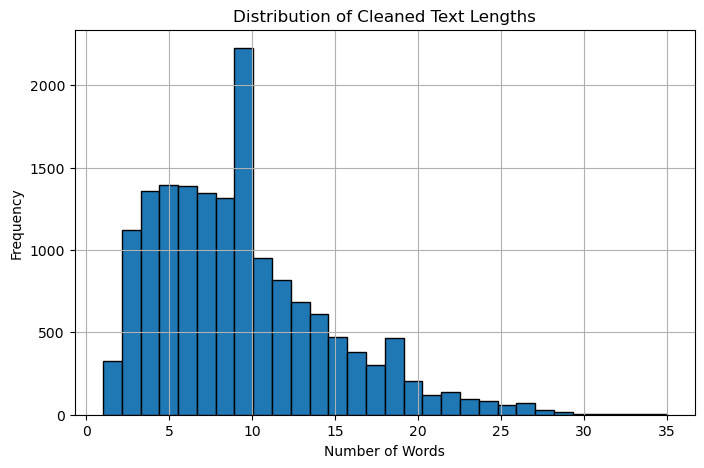

Average Text Length: 9.35
Minimum Text Length: 1
Maximum Text Length: 35

Observations:
1. Most cleaned texts contain a moderate number of words.
2. Very short and very long texts are fewer in number.
3. Cleaning removed unnecessary words and symbols, reducing text length.
4. The cleaned data is more suitable for NLP model training.


In [9]:
'''
Q9. Text Length Analysis
'''

import matplotlib.pyplot as plt

# Calculate Number of Words
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

# Plot Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df["text_length"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Cleaned Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

# Statistics
print("Average Text Length:", round(df["text_length"].mean(), 2))
print("Minimum Text Length:", df["text_length"].min())
print("Maximum Text Length:", df["text_length"].max())

# Observations
print("\nObservations:")
print("1. Most cleaned texts contain a moderate number of words.")
print("2. Very short and very long texts are fewer in number.")
print("3. Cleaning removed unnecessary words and symbols, reducing text length.")
print("4. The cleaned data is more suitable for NLP model training.")